# Graph2Vec Parameter Investigation

Standalone notebook for exploring how Graph2Vec parameters (`max_degree`, `min_count`, `epochs`) affect clustering quality — without running the full PyGVAMP pipeline.

**Workflow:**
1. Point to a cached dataset from a previous pipeline run (`.pkl` file)
2. Define parameter combinations to sweep
3. Run G2V + clustering for each combination
4. Compare results side-by-side

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.manifold import TSNE

from pygv.dataset.vampnet_dataset import VAMPNetDataset
from pygv.clustering.graph2vec import Graph2Vec

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("umap-learn not installed, UMAP projections will be skipped")

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

/opt/conda/conda/envs/PyGVAMP/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load dataset

Point to your trajectory and topology files. Uses the same `VAMPNetDataset` constructor as the pipeline.  
Adjust `selection`, `stride`, `n_neighbors` etc. to match your pipeline settings.

In [8]:
# --- EDIT THESE ---
TOPOLOGY = "/home/iwe81/vi/PYGVAMP/datasets/B2AR_4LDO/11109_dyn_116.pdb"
TRAJECTORIES = [
    "/home/iwe81/vi/PYGVAMP/datasets/B2AR_4LDO/11105_trj_116.xtc",
    # add more if needed
]

# Match your pipeline settings
SELECTION = "name CA"
STRIDE = 1
N_NEIGHBORS = 10
LAG_TIME = 200

dataset = VAMPNetDataset(
    trajectory_files=TRAJECTORIES,
    topology_file=TOPOLOGY,
    selection=SELECTION,
    stride=STRIDE,
    n_neighbors=N_NEIGHBORS,
    lag_time=LAG_TIME,
)
frames_ds = dataset.get_frames_dataset(return_pairs=False)
print(f"Loaded {len(frames_ds)} frames, {dataset.n_atoms} atoms")

Trajectory timestep: 200000.000 ps
Effective timestep with stride 1: 200000.000 ps
Lag time: 200.000 ns (200000.0 ps, 1 frames)
Processing 1 trajectory files...


Trajectory files:   0%|                                 | 0/1 [00:00<?, ?file/s]

Selected 303 atoms with selection: 'name CA'


Trajectory files: 100%|█████████████████████████| 1/1 [00:09<00:00,  9.66s/file]


Total frames: 2500, Atoms per frame: 303
Calculating distance range from data samples...


Computing distance range: 100%|█████████| 2500/2500 [00:04<00:00, 607.12frame/s]

Distance range: 0.33 to 9.19 Å
Created 2499 time-lagged pairs with lag time 200 and 1 lag frames. 1 lag frame == 200.0 ns
Loaded 2500 frames, 303 atoms


## 2. Define parameter grid

Each dict is one G2V run. Adjust freely and re-run.

In [ ]:
PARAM_GRID = [
    {"label": "baseline (deg=3, mc=10)",  "max_degree": 3, "min_count": 10, "epochs": 50},
    {"label": "deeper (deg=5, mc=10)",    "max_degree": 5, "min_count": 10, "epochs": 50},
    {"label": "deeper+loose (deg=5, mc=3)", "max_degree": 5, "min_count": 3,  "epochs": 50},
    {"label": "deep+long (deg=5, mc=3, ep=100)", "max_degree": 5, "min_count": 3, "epochs": 100},
    # min_count_decay: degree 0 uses min_count, each deeper degree multiplies by decay
    # e.g. mc=10, decay=0.5 -> d0:10, d1:5, d2:2, d3:1, d4:1, d5:1
    {"label": "decay (deg=5, mc=10, decay=0.5)", "max_degree": 5, "min_count": 10, "min_count_decay": 0.5, "epochs": 50},
    {"label": "decay+long (deg=5, mc=10, decay=0.5, ep=100)", "max_degree": 5, "min_count": 10, "min_count_decay": 0.5, "epochs": 100},
]

# Shared settings
EMBEDDING_DIM = 512
MIN_K, MAX_K = 2, 10
RANDOM_STATE = 42

## 3. Run G2V + clustering sweep

Trains Graph2Vec for each parameter set, extracts embeddings, runs KMeans for k in `[MIN_K, MAX_K]`, and stores everything for comparison.

In [ ]:
import time
import warnings

results = {}

for params in PARAM_GRID:
    label = params["label"]
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")

    t0 = time.time()

    # Train Graph2Vec
    g2v = Graph2Vec(
        embedding_dim=EMBEDDING_DIM,
        max_degree=params["max_degree"],
        min_count=params["min_count"],
        min_count_decay=params.get("min_count_decay", None),
        epochs=params["epochs"],
        batch_size=64,
        num_workers=4,
    )
    g2v.fit(frames_ds, len(frames_ds))
    embeddings = g2v.get_embeddings().numpy()

    # Pairwise cosine similarity (sample)
    sample_n = min(200, len(embeddings))
    idxs = np.random.RandomState(RANDOM_STATE).choice(len(embeddings), sample_n, replace=False)
    norms = np.linalg.norm(embeddings[idxs], axis=1, keepdims=True) + 1e-8
    normed = embeddings[idxs] / norms
    cos_sim = normed @ normed.T
    triu = cos_sim[np.triu_indices(sample_n, k=1)]

    # KMeans sweep
    k_range = list(range(MIN_K, MAX_K + 1))
    silhouettes, inertias, all_labels = {}, {}, {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labs = km.fit_predict(embeddings)
        all_labels[k] = labs
        inertias[k] = km.inertia_
        if k >= 2:
            silhouettes[k] = silhouette_score(embeddings, labs)

    best_sil_k = max(silhouettes, key=silhouettes.get)
    elapsed = time.time() - t0

    # 2D projections (for visualization later)
    tsne_2d = TSNE(n_components=2, random_state=RANDOM_STATE,
                   perplexity=min(30, len(embeddings) - 1),
                   max_iter=1000).fit_transform(embeddings)
    umap_2d = None
    if HAS_UMAP:
        umap_2d = umap.UMAP(n_components=2, random_state=RANDOM_STATE,
                            n_neighbors=min(15, len(embeddings) - 1),
                            min_dist=0.1).fit_transform(embeddings)

    results[label] = {
        "params": params,
        "embeddings": embeddings,
        "vocab_size": g2v.vocab_size,
        "min_count_per_degree": dict(g2v.min_count_per_degree),
        "cos_sim_mean": float(np.mean(triu)),
        "cos_sim_std": float(np.std(triu)),
        "silhouettes": silhouettes,
        "inertias": inertias,
        "labels": all_labels,
        "best_sil_k": best_sil_k,
        "tsne_2d": tsne_2d,
        "umap_2d": umap_2d,
        "elapsed": elapsed,
    }

    print(f"\n  vocab={g2v.vocab_size}, cos_sim={np.mean(triu):.3f}+/-{np.std(triu):.3f}, "
          f"best_k={best_sil_k} (sil={silhouettes[best_sil_k]:.3f}), {elapsed:.1f}s")

print("\nAll runs complete.")

## 4. Summary table

In [11]:
header = f"{'Label':<40} {'Vocab':>6} {'CosSim':>10} {'Best k':>7} {'Sil':>7} {'Time':>7}"
print(header)
print("-" * len(header))
for label, r in results.items():
    print(f"{label:<40} {r['vocab_size']:>6} "
          f"{r['cos_sim_mean']:>6.3f}+/-{r['cos_sim_std']:.3f}"
          f"{r['best_sil_k']:>5} {r['silhouettes'][r['best_sil_k']]:>8.3f}"
          f"{r['elapsed']:>6.0f}s")

Label                                     Vocab     CosSim  Best k     Sil    Time
----------------------------------------------------------------------------------
baseline (deg=3, mc=10)                    5450  0.290+/-0.136    2    0.068    84s
deeper (deg=5, mc=10)                      5450  0.290+/-0.137    2    0.069   310s
deeper+loose (deg=5, mc=3)                42160  0.250+/-0.110    2    0.039   356s
deep+long (deg=5, mc=3, ep=100)           42160  0.209+/-0.063    6    0.014   331s


## 5. Silhouette & Elbow comparison

All parameter sets on one plot for direct comparison.

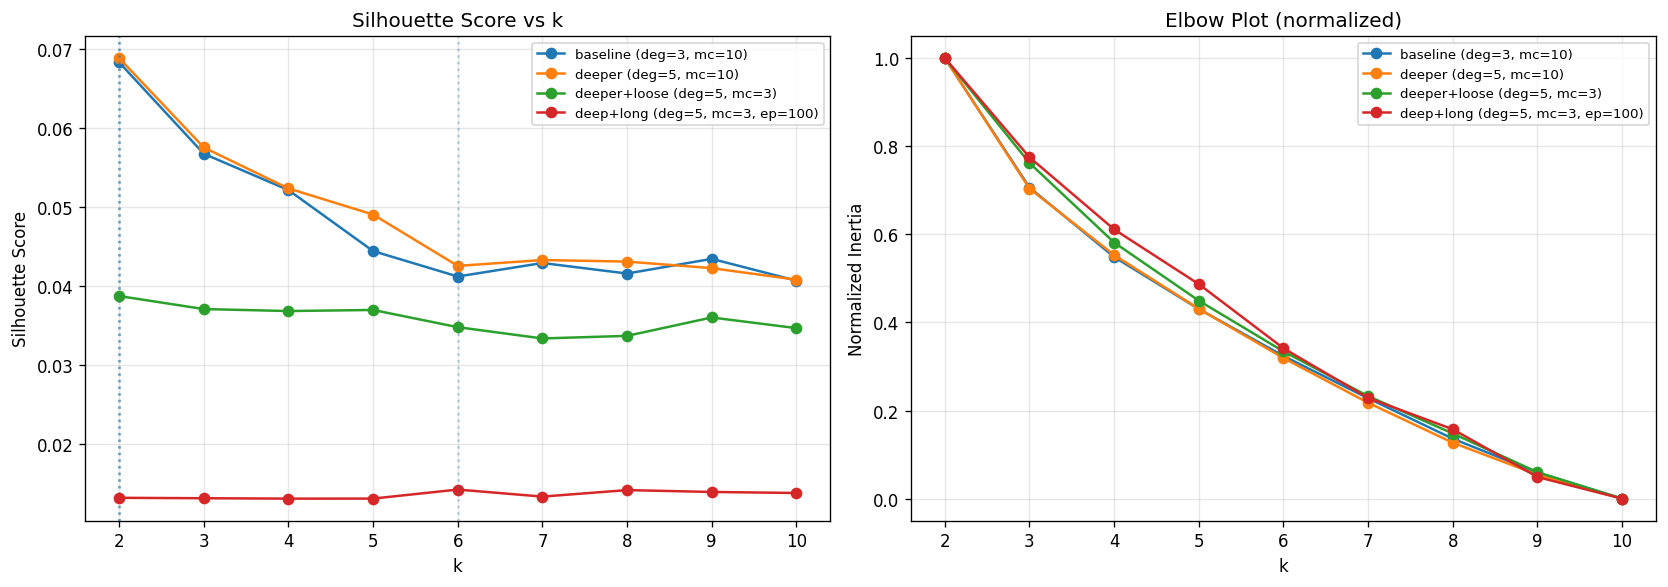

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for label, r in results.items():
    ks = sorted(r["silhouettes"].keys())
    ax1.plot(ks, [r["silhouettes"][k] for k in ks], 'o-', label=label)
    ax1.axvline(r["best_sil_k"], linestyle=':', alpha=0.3)

    ks_i = sorted(r["inertias"].keys())
    # Normalize inertia to [0,1] for comparison across runs
    inerts = np.array([r["inertias"][k] for k in ks_i])
    inerts_norm = (inerts - inerts.min()) / (inerts.max() - inerts.min() + 1e-8)
    ax2.plot(ks_i, inerts_norm, 'o-', label=label)

ax1.set_xlabel("k")
ax1.set_ylabel("Silhouette Score")
ax1.set_title("Silhouette Score vs k")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

ax2.set_xlabel("k")
ax2.set_ylabel("Normalized Inertia")
ax2.set_title("Elbow Plot (normalized)")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Cosine similarity distributions

Low mean + high spread = diverse, discriminative embeddings.  
High mean + low spread = embeddings are collapsing (bad).

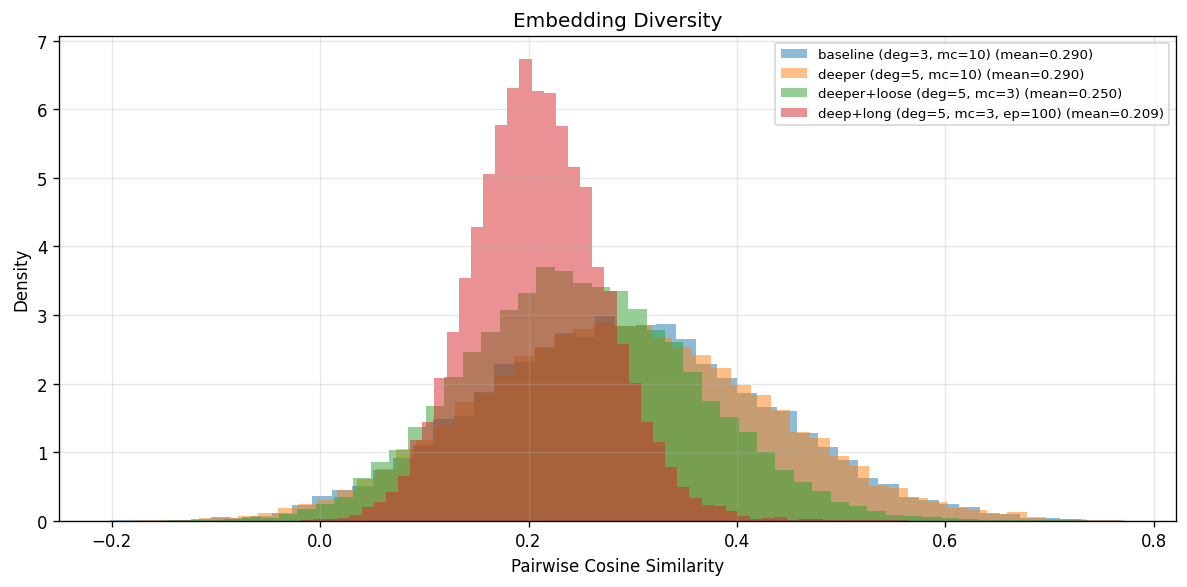

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

for label, r in results.items():
    emb = r["embeddings"]
    sample_n = min(200, len(emb))
    idxs = np.random.RandomState(RANDOM_STATE).choice(len(emb), sample_n, replace=False)
    norms = np.linalg.norm(emb[idxs], axis=1, keepdims=True) + 1e-8
    normed = emb[idxs] / norms
    cs = normed @ normed.T
    triu = cs[np.triu_indices(sample_n, k=1)]
    ax.hist(triu, bins=50, alpha=0.5, density=True, label=f"{label} (mean={np.mean(triu):.3f})")

ax.set_xlabel("Pairwise Cosine Similarity")
ax.set_ylabel("Density")
ax.set_title("Embedding Diversity")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 2D embedding scatter (t-SNE / UMAP)

Each parameter set in its own subplot, colored by best-k clustering.

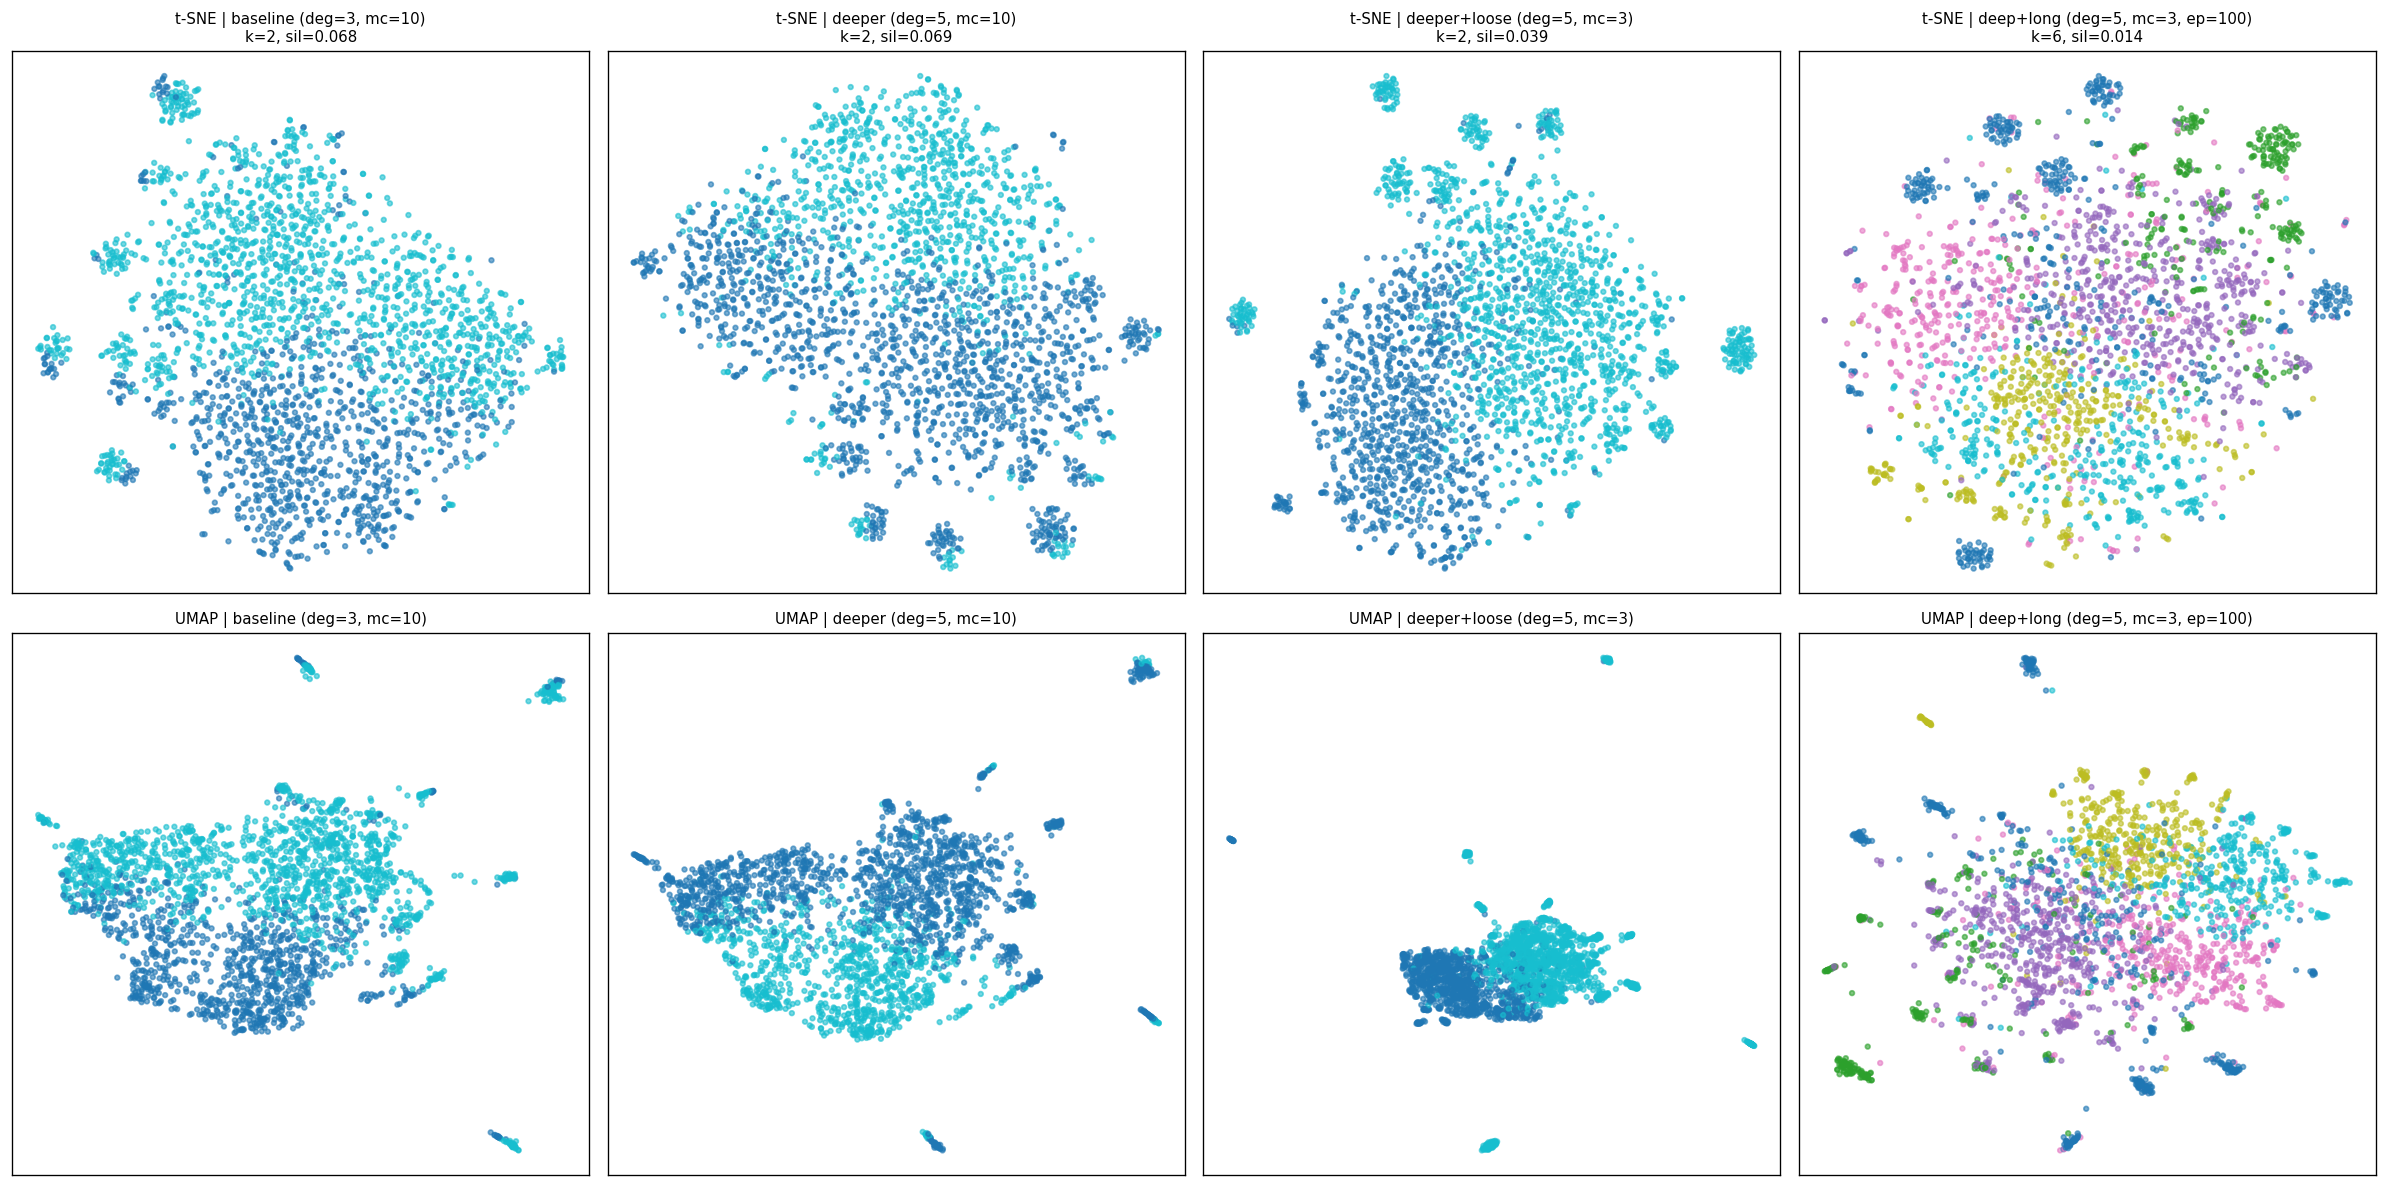

In [14]:
n_runs = len(results)
fig, axes = plt.subplots(2, n_runs, figsize=(5 * n_runs, 10))
if n_runs == 1:
    axes = axes.reshape(2, 1)

for col, (label, r) in enumerate(results.items()):
    k = r["best_sil_k"]
    labs = r["labels"][k]
    colors = plt.cm.tab10(labs / max(labs.max(), 1))

    # t-SNE row
    ax = axes[0, col]
    ax.scatter(r["tsne_2d"][:, 0], r["tsne_2d"][:, 1], c=colors, s=8, alpha=0.6)
    ax.set_title(f"t-SNE | {label}\nk={k}, sil={r['silhouettes'][k]:.3f}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

    # UMAP row
    ax = axes[1, col]
    if r["umap_2d"] is not None:
        ax.scatter(r["umap_2d"][:, 0], r["umap_2d"][:, 1], c=colors, s=8, alpha=0.6)
        ax.set_title(f"UMAP | {label}", fontsize=9)
    else:
        ax.text(0.5, 0.5, "UMAP\nnot available", ha='center', va='center', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

## 8. Silhouette breakdown per cluster

Shows per-sample silhouette values grouped by cluster for the best-k of each run. Thin/negative bars indicate poorly separated states.

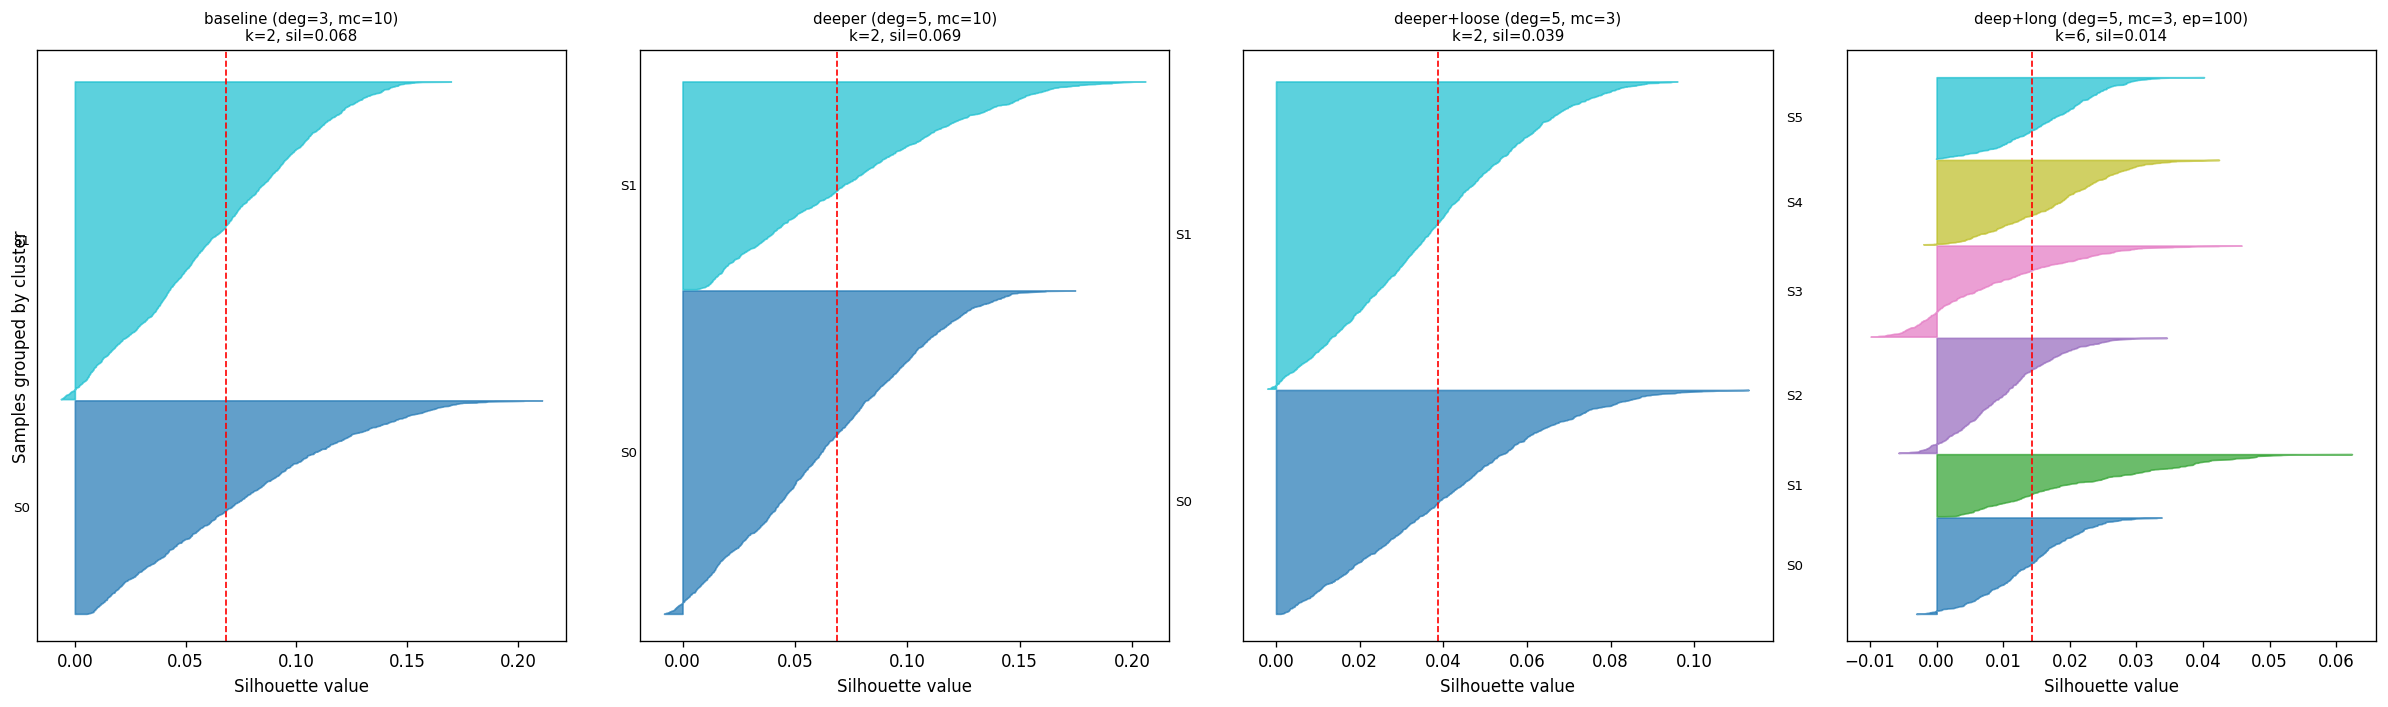

In [15]:
n_runs = len(results)
fig, axes = plt.subplots(1, n_runs, figsize=(5 * n_runs, 6), sharey=True)
if n_runs == 1:
    axes = [axes]

for ax, (label, r) in zip(axes, results.items()):
    k = r["best_sil_k"]
    labs = r["labels"][k]
    emb = r["embeddings"]
    sample_sil = silhouette_samples(emb, labs)

    y_lower = 0
    for i in range(k):
        cluster_sil = np.sort(sample_sil[labs == i])
        size = len(cluster_sil)
        color = plt.cm.tab10(i / max(k - 1, 1))
        ax.fill_betweenx(np.arange(y_lower, y_lower + size), 0, cluster_sil,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.02, y_lower + size / 2, f"S{i}", fontsize=8, va='center', ha='right')
        y_lower += size + 5

    ax.axvline(r["silhouettes"][k], color='red', linestyle='--', linewidth=1)
    ax.set_title(f"{label}\nk={k}, sil={r['silhouettes'][k]:.3f}", fontsize=9)
    ax.set_xlabel("Silhouette value")
    ax.set_yticks([])

axes[0].set_ylabel("Samples grouped by cluster")
plt.tight_layout()
plt.show()

## 9. Cluster sizes & temporal evolution

Left: population balance. Right: state assignments over frame index (time).

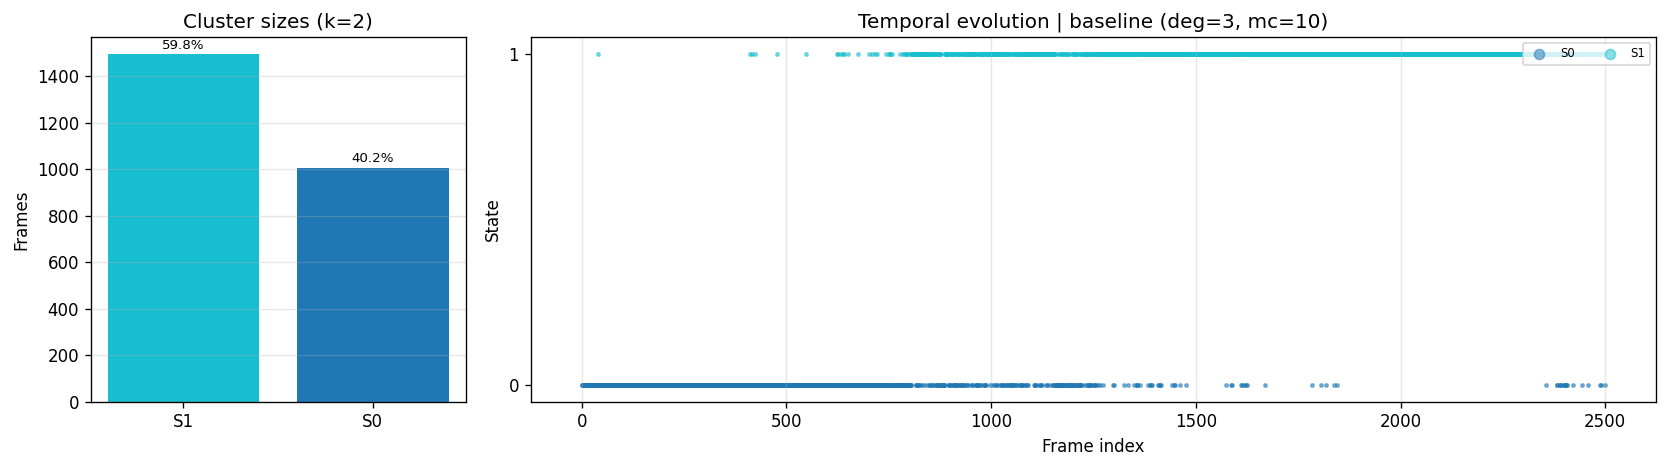

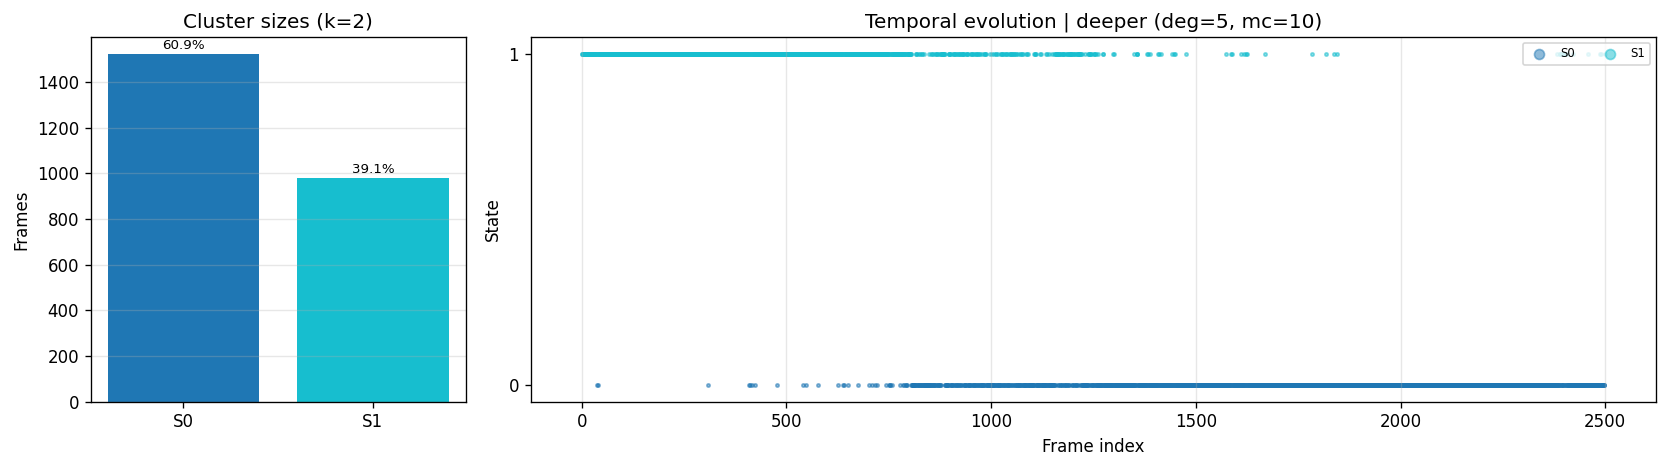

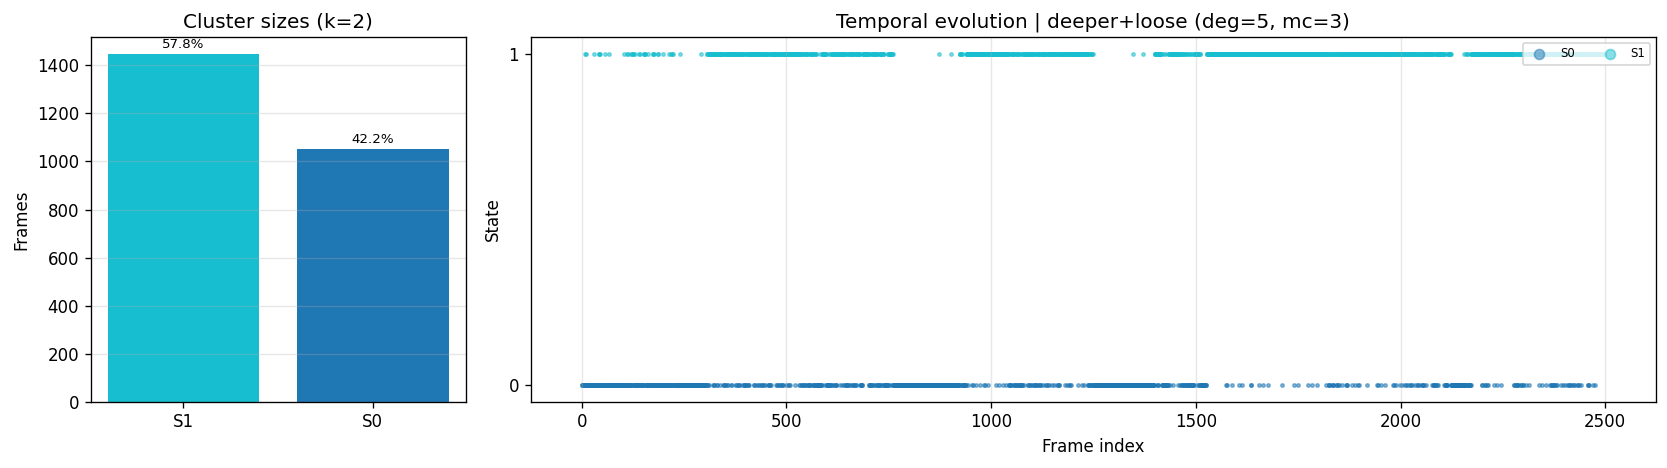

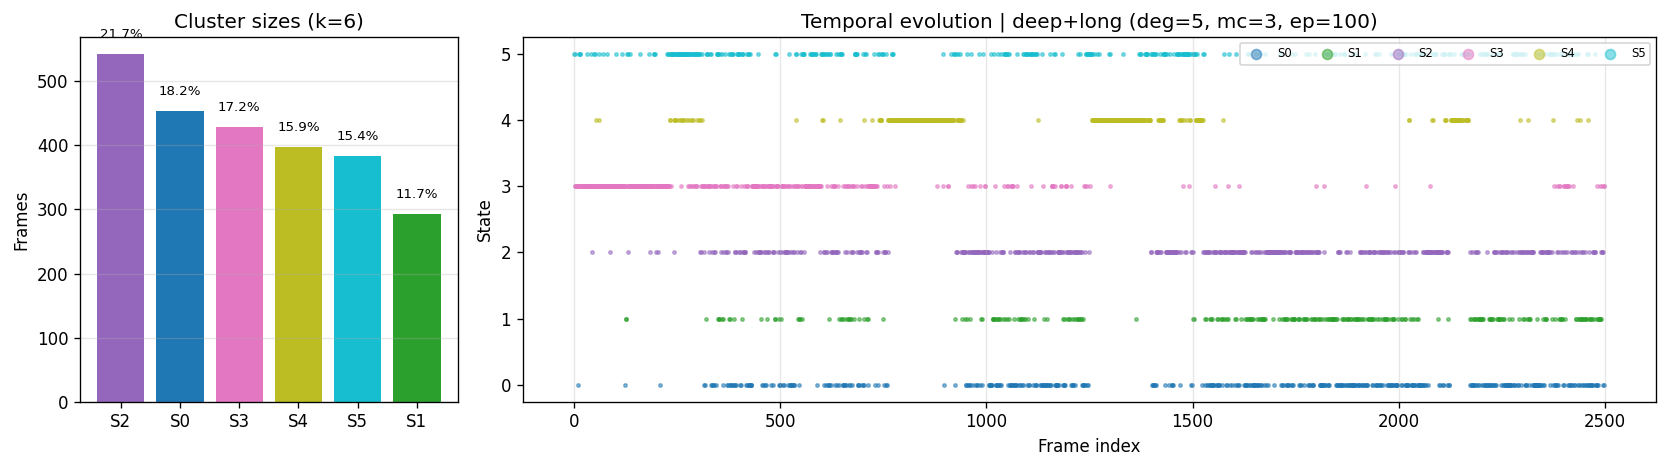

In [16]:
for label, r in results.items():
    k = r["best_sil_k"]
    labs = r["labels"][k]
    n_frames = len(labs)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4),
                                    gridspec_kw={"width_ratios": [1, 3]})

    # Cluster sizes
    unique, counts = np.unique(labs, return_counts=True)
    sorted_idx = np.argsort(counts)[::-1]
    colors = [plt.cm.tab10(u / max(k - 1, 1)) for u in unique[sorted_idx]]
    bars = ax1.bar(range(len(unique)), counts[sorted_idx], color=colors)
    for i, (cnt, u) in enumerate(zip(counts[sorted_idx], unique[sorted_idx])):
        ax1.text(i, cnt + n_frames * 0.01, f"{100*cnt/n_frames:.1f}%",
                 ha='center', fontsize=8)
    ax1.set_xticks(range(len(unique)))
    ax1.set_xticklabels([f"S{u}" for u in unique[sorted_idx]])
    ax1.set_ylabel("Frames")
    ax1.set_title(f"Cluster sizes (k={k})")
    ax1.grid(alpha=0.3, axis='y')

    # Timeline
    frame_idx = np.arange(n_frames)
    for u in unique:
        mask = labs == u
        color = plt.cm.tab10(u / max(k - 1, 1))
        ax2.scatter(frame_idx[mask], labs[mask], c=[color], s=4, alpha=0.5, label=f"S{u}")
    ax2.set_xlabel("Frame index")
    ax2.set_ylabel("State")
    ax2.set_yticks(unique)
    ax2.set_title(f"Temporal evolution | {label}")
    ax2.legend(loc='upper right', fontsize=7, ncol=k, markerscale=3)
    ax2.grid(alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

## 10. Override k manually

If you want to inspect clustering at a specific k (not just the silhouette-optimal), pick a run and k below.

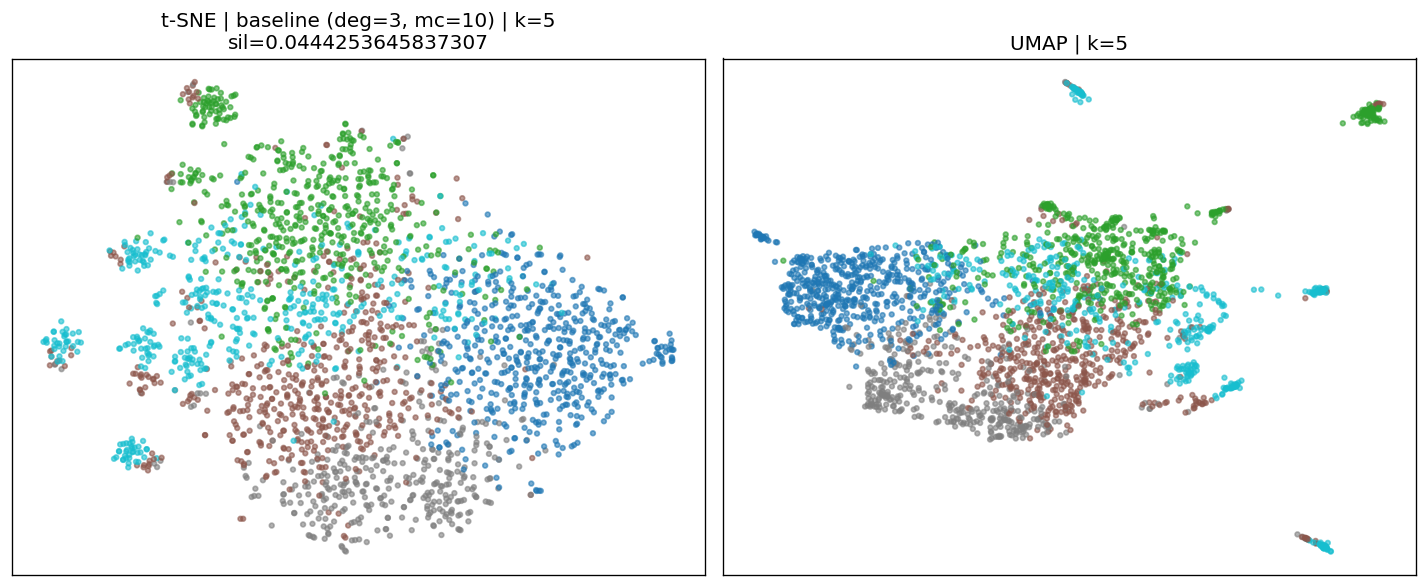

In [17]:
PICK_LABEL = list(results.keys())[0]  # <-- change to the run you want
PICK_K = 5                             # <-- change to the k you want

r = results[PICK_LABEL]
labs = r["labels"][PICK_K]
colors = plt.cm.tab10(labs / max(labs.max(), 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(r["tsne_2d"][:, 0], r["tsne_2d"][:, 1], c=colors, s=8, alpha=0.6)
ax1.set_title(f"t-SNE | {PICK_LABEL} | k={PICK_K}\nsil={r['silhouettes'].get(PICK_K, 'N/A')}")
ax1.set_xticks([]); ax1.set_yticks([])

if r["umap_2d"] is not None:
    ax2.scatter(r["umap_2d"][:, 0], r["umap_2d"][:, 1], c=colors, s=8, alpha=0.6)
    ax2.set_title(f"UMAP | k={PICK_K}")
else:
    ax2.text(0.5, 0.5, "UMAP not available", ha='center', va='center', transform=ax2.transAxes)
ax2.set_xticks([]); ax2.set_yticks([])

plt.tight_layout()
plt.show()